In [208]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_excel('backup.xlsx')

Forecasting with RandomForestRegressor

In [173]:
_df = df.copy()

_df['Date'] = pd.to_datetime(_df['Date'], errors='coerce')
if 'Time' in _df.columns:
    _df['Time'] = pd.to_datetime(_df['Time'], errors='coerce')
    _df['hour'] = _df['Time'].dt.hour
_df['dayOfWeek'] = _df['Date'].dt.dayofweek
_df['month']     = _df['Date'].dt.month

# Lag features
_df = _df.sort_values(['Cinema', 'Auditorium', 'Date'])
_df['occupacyRate_lag1'] = _df.groupby(['Cinema', 'Auditorium'])['occupacyRate'].shift(1)
_df = _df.dropna(subset=['occupacyRate_lag1'])

numeric_features = ['durationMin', 'quantityPlan', 'profitPlan',
    'averageRating', 'numVotes', 'budget', 'revenue',
    'ticketPriceReal', 'populationCity',
    'hour', 'dayOfWeek', 'month',
    'occupacyRate_lag1']

categorical_features = ['Cinema', 'Auditorium', 'Technology',
    'sessionCanceled', 'isPremiere',
    'mpaaRating', 'period', 'seatType']

/var/folders/bt/_x0h2pb92g55h0wvnfmyf_900000gp/T/ipykernel_30371/667693247.py:3: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  _df['Date'] = pd.to_datetime(_df['Date'], errors='coerce')


In [174]:
y_train = None

dataset = _df.dropna(subset=numeric_features + categorical_features + ['occupacyRate'])

# 4) Time-based split 10 months - 2 months
cutoff = pd.to_datetime('2019-10-31')
train = dataset[dataset['Date'] <= cutoff]
test  = dataset[dataset['Date']  > cutoff]
print(f"Train samples: {train.shape[0]}, Test samples: {test.shape[0]}")
if test.shape[0] == 0:
    raise ValueError(f"Test set is empty after cutoff {cutoff.date()}")

X_train = train[numeric_features + categorical_features]
y_train = train['occupacyRate']
X_test  = test[numeric_features + categorical_features]
y_test  = test['occupacyRate']


Train samples: 145788, Test samples: 36772


In [175]:
y_train = None

dataset = _df.dropna(subset=numeric_features + categorical_features + ['occupacyRate'])

# 4) Time-based split
cutoff = pd.to_datetime('2019-10-31')
train = dataset[dataset['Date'] <= cutoff]
test  = dataset[dataset['Date']  > cutoff]
print(f"Train samples: {train.shape[0]}, Test samples: {test.shape[0]}")
if test.shape[0] == 0:
    raise ValueError(f"Test set is empty after cutoff {cutoff.date()}")

X_train = train[numeric_features + categorical_features]
y_train = train['occupacyRate']
X_test  = test[numeric_features + categorical_features]
y_test  = test['occupacyRate']

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ]), categorical_features)
], remainder='drop')

model = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")
print(f"Test R²  : {r2:.4f}")

Train samples: 145788, Test samples: 36772


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Test RMSE: 0.1934
Test MAE : 0.1466
Test R²  : 0.6053


In [176]:
print(f"Test MSE  : {mean_squared_error(y_test, y_pred, squared=True):.4f}")

Test MSE  : 0.0374


Train samples: 145788, Test samples: 36772


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-package

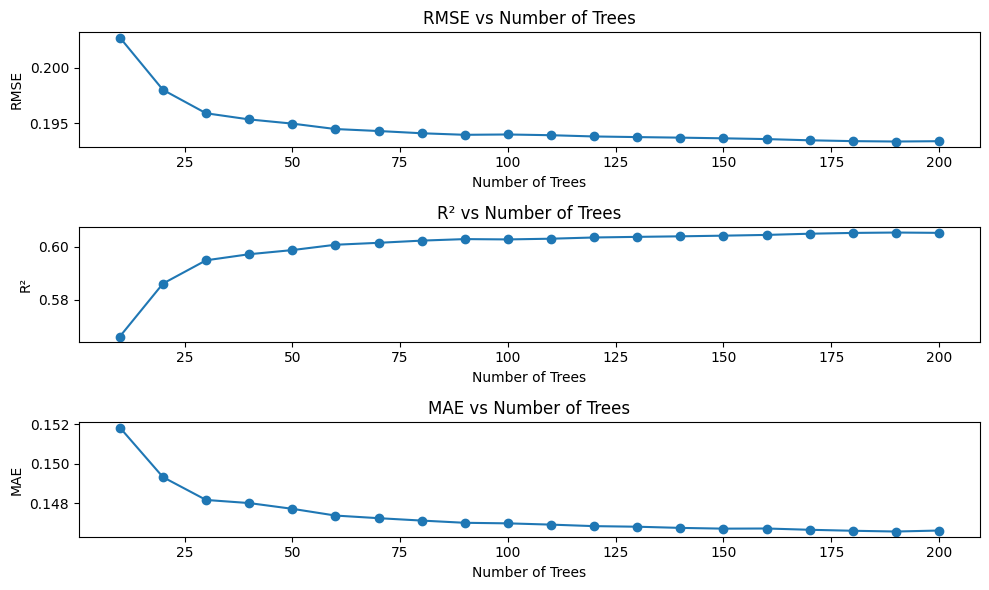

In [209]:
y_train = None
dataset = _df.dropna(subset=numeric_features + categorical_features + ['occupacyRate'])

cutoff = pd.to_datetime('2019-10-31')
train = dataset[dataset['Date'] <= cutoff]
test  = dataset[dataset['Date']  > cutoff]
print(f"Train samples: {train.shape[0]}, Test samples: {test.shape[0]}")
if test.shape[0] == 0:
    raise ValueError(f"Test set is empty after cutoff {cutoff.date()}")

X_train = train[numeric_features + categorical_features]
y_train = train['occupacyRate']
X_test  = test[numeric_features + categorical_features]
y_test  = test['occupacyRate']

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ]), categorical_features)
], remainder='drop')

model = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

n_estimators_range = list(range(10, 201, 10))
rmse_scores = []
r2_scores = []
mae_scores = []

for n_estimators in n_estimators_range:
    model.set_params(reg__n_estimators=n_estimators)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mae_scores.append(mae)


plt.figure(figsize=(10, 6))

# RMSE plot
plt.subplot(3, 1, 1)
plt.plot(n_estimators_range, rmse_scores, marker='o')
plt.title('RMSE vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')

# R² plot
plt.subplot(3, 1, 2)
plt.plot(n_estimators_range, r2_scores, marker='o')
plt.title('R² vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('R²')

# MAE plot
plt.subplot(3, 1, 3)
plt.plot(n_estimators_range, mae_scores, marker='o')
plt.title('MAE vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()


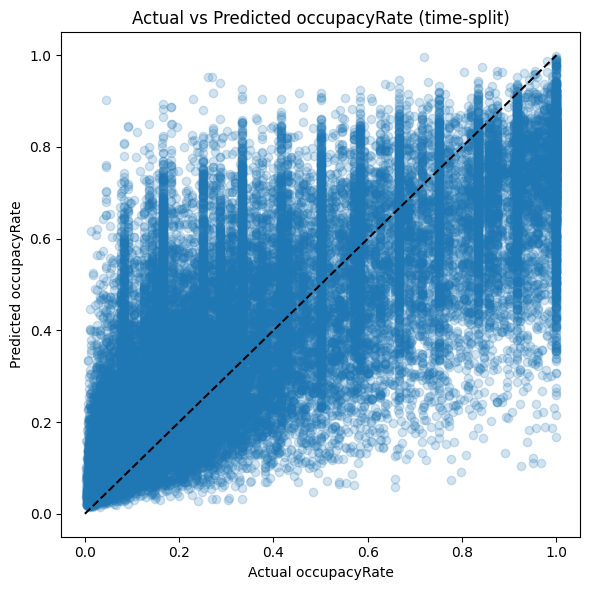

In [177]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([0,1], [0,1], 'k--')  # линия 45°
plt.xlabel('Actual occupacyRate')
plt.ylabel('Predicted occupacyRate')
plt.title('Actual vs Predicted occupacyRate (time-split)')
plt.tight_layout()
plt.show()

Residuals mean=-0.0176, std=0.1926


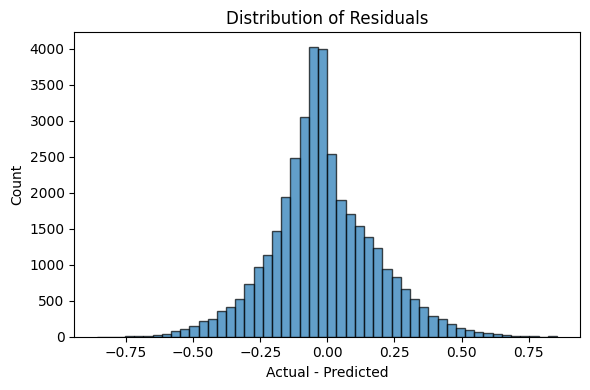

In [178]:
residuals = y_test - y_pred
print(f"Residuals mean={residuals.mean():.4f}, std={residuals.std():.4f}")
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Actual - Predicted')
plt.ylabel('Count')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

Top 15 Feature Importances:
occupacyRate_lag1       0.259824
quantityPlan            0.189672
ticketPriceReal         0.088989
hour                    0.082336
profitPlan              0.053302
dayOfWeek               0.034129
revenue                 0.032847
durationMin             0.029143
month                   0.028840
numVotes                0.028013
averageRating           0.020081
budget                  0.018558
seatType_VIP - місце    0.012676
Cinema_Cinema 1L        0.009460
populationCity          0.009225
dtype: float64


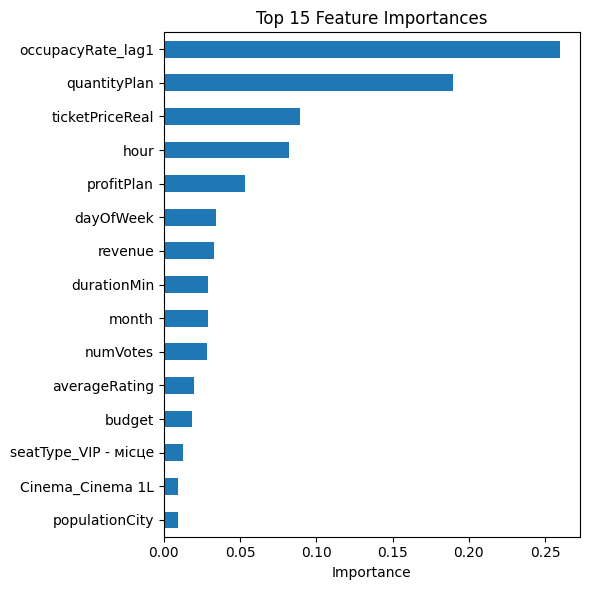

In [179]:
# Feature importance
importances = model.named_steps['reg'].feature_importances_
feature_names = (
    numeric_features +
    list(model.named_steps['prep'].named_transformers_['cat']
         .named_steps['ohe']
         .get_feature_names_out(categorical_features))
)
feat_imp = pd.Series(importances, index=feature_names).nlargest(15)

print("Top 15 Feature Importances:")
print(feat_imp)
plt.figure(figsize=(6,6))
feat_imp.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()


Implementing algorithm on a random day in a random cinema

In [180]:
df_ = _df[_df['Cinema'] == 'Cinema 1L']

In [181]:
df_ = df_[df_['Date'] == '15.12.2019']

/var/folders/bt/_x0h2pb92g55h0wvnfmyf_900000gp/T/ipykernel_30371/4100222806.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df_ = df_[df_['Date'] == '15.12.2019']


In [182]:
movie_features = [
    'Film',              
    'durationMin',      
    'Distributor',
    'Studio',
    'genres',
    'directors',
    'averageRating',
    'numVotes',
    'productionCountries',
    'mpaaRating',
    'budget',
    'revenue',
    'originalLanguage',
    'isPremiere',        
]

session_features = [
    'Number',
    'Cinema',          
    'cinemaCity',
    'populationCity',
    'Auditorium',        
    'Technology',      
    'sessionCanceled',    
    'Date',
    'Time',
    'week',
    'dayOfWeek',
    'month',
    'hour',
    'period',         
    'seatType',           
    'quantityPlan',
    'quantitySold',
    'quantityUnsold',
    'ticketPriceReal',
    'profitEarned',
    'profitPlan',
    'profitRatio',
    'occupacyRate_lag1',  
]

In [183]:
session_df = df_[session_features]
films_df = df_[movie_features]

In [184]:
#  unique films and sessions
unique_films = df_['Film'].unique()
unique_sessions = df_['Number'].unique()

print(f"Number of unique sessions: {len(unique_sessions)}")  # Should be 40

# clean pairs dataframe
# This is a Cartesian product (all combinations)
pairs = []
for film in unique_films:
    film_data = df_[df_['Film'] == film].iloc[0]
    for session_num in unique_sessions:
        session_data = df_[df_['Number'] == session_num].iloc[0]
        
        x = {}
        for col in df_.select_dtypes(include=np.number).columns.tolist():
            if col in session_features:
                x[col] = session_data[col]
            elif col in movie_features:
                x[col] = film_data[col]
            else:
                x[col] = np.nan
                
        # Session features
        for col in ['Cinema', 'Auditorium', 'Technology', 'sessionCanceled', 
                   'period', 'seatType', 'Date', 'Time', 'week', 'cinemaCity', 
                   'populationCity']:
            x[col] = session_data[col]
            
        # Movie features
        for col in ['Film', 'Distributor', 'Studio', 'genres', 'directors', 
                   'originalLanguage', 'productionCountries', 'mpaaRating', 
                   'isPremiere']:
            x[col] = film_data[col]
            
        pairs.append({
            'film': film,
            'Number': session_num,
            **x
        })

df_pairs = pd.DataFrame(pairs)

Number of unique sessions: 40


In [185]:
X_pairs = df_pairs[df_.columns]
df_pairs['pred_occupRate'] = model.predict(X_pairs)

In [186]:
movie_prefs = {
    film: 
    df_pairs[df_pairs['Film']==film]
      .sort_values('pred_occupRate', ascending=False)
      ['Number']
      .tolist()
    for film in unique_films
}

session_prefs = {
    sess:
    df_pairs[df_pairs['Number']==sess]
      .sort_values('pred_occupRate', ascending=False)
      ['film']
      .tolist()
    for sess in unique_sessions
}

for film, prefs in movie_prefs.items():
    print(f"Film: {film}, Number of preferences: {len(prefs)}")
    # Each film should have exactly 40 preferences (one for each session)
    assert len(prefs) == len(unique_sessions)

for sess, prefs in session_prefs.items():
    print(f"Session: {sess}, Number of preferences: {len(prefs)}")
    # Each session should have preferences for all unique films
    assert len(prefs) == len(unique_films)

Film: ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ, Number of preferences: 40
Film: АУТСАЙДЕРИ, Number of preferences: 40
Film: Крижане серце 2, Number of preferences: 40
Film: АЕРОНАВТИ, Number of preferences: 40
Film: НОЖІ НАГОЛО, Number of preferences: 40
Film: КОРОЛЬ ВІСЛЮК, Number of preferences: 40
Film: ЧОРНИЙ ВОРОН, Number of preferences: 40
Film: ЗВІРОПОЛЮС, Number of preferences: 40
Film: БЕРЛІНСЬКИЙ ФЕЙСКОНТРОЛЬНИК, Number of preferences: 40
Film: ЦІНА ПРАВДИ 2019, Number of preferences: 40
Film: ХТО ТВОЯ БАБЦЯ, ЧУВАЧЕ!?, Number of preferences: 40
Film: ФАБРИКА МРІЙ, Number of preferences: 40
Film: КУРЄР, Number of preferences: 40
Film: 21 МІСТ, Number of preferences: 40
Film: МОСЛІ, Number of preferences: 40
Film: АБАТСТВО ДАУНТОН, Number of preferences: 40
Session: 670382.0, Number of preferences: 16
Session: 670401.0, Number of preferences: 16
Session: 670366.0, Number of preferences: 16
Session: 670383.0, Number of preferences: 16
Session: 670384.0, Number of preferences: 16
Session: 670

In [187]:
movie_prefs

{'ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ': [670466.0,
  670559.0,
  660170.0,
  670620.0,
  670595.0,
  670577.0,
  670384.0,
  670464.0,
  670383.0,
  670515.0,
  670578.0,
  670420.0,
  670502.0,
  670588.0,
  670465.0,
  670495.0,
  670366.0,
  670602.0,
  670543.0,
  670441.0,
  670619.0,
  670480.0,
  670532.0,
  671479.0,
  670514.0,
  670442.0,
  670419.0,
  670401.0,
  670542.0,
  670463.0,
  670385.0,
  670418.0,
  670553.0,
  670487.0,
  670525.0,
  670567.0,
  670382.0,
  670609.0,
  670443.0,
  670417.0],
 'АУТСАЙДЕРИ': [670559.0,
  670620.0,
  670595.0,
  660170.0,
  670466.0,
  670515.0,
  670577.0,
  670502.0,
  670588.0,
  670495.0,
  670384.0,
  670383.0,
  670543.0,
  670441.0,
  670464.0,
  670578.0,
  670465.0,
  670420.0,
  670366.0,
  670619.0,
  670602.0,
  670480.0,
  671479.0,
  670401.0,
  670419.0,
  670532.0,
  670514.0,
  670463.0,
  670442.0,
  670542.0,
  670385.0,
  670418.0,
  670553.0,
  670609.0,
  670525.0,
  670382.0,
  670567.0,
  670487.0,
  670417.0,
  6704

In [188]:
session_prefs

{670382.0: ['АУТСАЙДЕРИ',
  'НОЖІ НАГОЛО',
  'Крижане серце 2',
  'ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ',
  'АБАТСТВО ДАУНТОН',
  'ЧОРНИЙ ВОРОН',
  'ФАБРИКА МРІЙ',
  'АЕРОНАВТИ',
  '21 МІСТ',
  'ХТО ТВОЯ БАБЦЯ, ЧУВАЧЕ!?',
  'ЗВІРОПОЛЮС',
  'ЦІНА ПРАВДИ 2019',
  'КОРОЛЬ ВІСЛЮК',
  'МОСЛІ',
  'КУРЄР',
  'БЕРЛІНСЬКИЙ ФЕЙСКОНТРОЛЬНИК'],
 670401.0: ['ЗВІРОПОЛЮС',
  'НОЖІ НАГОЛО',
  'АУТСАЙДЕРИ',
  'ХТО ТВОЯ БАБЦЯ, ЧУВАЧЕ!?',
  'ЦІНА ПРАВДИ 2019',
  '21 МІСТ',
  'БЕРЛІНСЬКИЙ ФЕЙСКОНТРОЛЬНИК',
  'АБАТСТВО ДАУНТОН',
  'АЕРОНАВТИ',
  'ЧОРНИЙ ВОРОН',
  'МОСЛІ',
  'ФАБРИКА МРІЙ',
  'КОРОЛЬ ВІСЛЮК',
  'ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ',
  'Крижане серце 2',
  'КУРЄР'],
 670366.0: ['Крижане серце 2',
  'АУТСАЙДЕРИ',
  'ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ',
  'КУРЄР',
  'НОЖІ НАГОЛО',
  'АБАТСТВО ДАУНТОН',
  'ЗВІРОПОЛЮС',
  'ХТО ТВОЯ БАБЦЯ, ЧУВАЧЕ!?',
  'МОСЛІ',
  'ЧОРНИЙ ВОРОН',
  'КОРОЛЬ ВІСЛЮК',
  'ЦІНА ПРАВДИ 2019',
  'БЕРЛІНСЬКИЙ ФЕЙСКОНТРОЛЬНИК',
  '21 МІСТ',
  'ФАБРИКА МРІЙ',
  'АЕРОНАВТИ'],
 670383.0: ['Крижане с

In [189]:
def session_optimal_matching(session_prefs, movie_quotas):
    """
    Implement a modified Gale-Shapley algorithm for stable matching where:
    - Sessions can only be assigned one movie
    - Movies can be assigned to multiple sessions (up to their quota)
    
    Parameters:
    - session_prefs: Dictionary mapping each session to its ranked list of movies
    - movie_quotas: Dictionary mapping each movie to the number of sessions it can be assigned to
    
    Returns:
    - Dictionary mapping each session to its matched movie
    """
    print("Running session-optimal matching algorithm...")
    
    session_to_movie = {}
    
    # inverse preferences of movies
    movie_ranks = {}
    for movie in movie_quotas.keys():
        # rank dictionary for each movie
        movie_ranks[movie] = {}
    
    for session, movies in session_prefs.items():
        for rank, movie in enumerate(movies):
            movie_ranks[movie][session] = rank
    # queue of unmatched sessions
    unassigned_sessions = list(session_prefs.keys())
    # dictionary to keep track of the next preference for each session
    next_proposal = {session: 0 for session in session_prefs}
    # dictionary to keep track of current assignments for each movie
    movie_assignments = {movie: [] for movie in movie_quotas}
    
    while unassigned_sessions:
        session = unassigned_sessions.pop(0)
        
        if next_proposal[session] >= len(session_prefs[session]):
            continue
        
        # next preferred movie for this session
        movie = session_prefs[session][next_proposal[session]]
        next_proposal[session] += 1
        
        if len(movie_assignments[movie]) < movie_quotas[movie]:
            movie_assignments[movie].append(session)
            session_to_movie[session] = movie
        else:
            # check if it prefers this session over any current assignment
            current_sessions = movie_assignments[movie]
            worst_session = max(current_sessions, key=lambda s: movie_ranks[movie].get(s, float('inf')))
            worst_rank = movie_ranks[movie].get(worst_session, float('inf'))
            current_rank = movie_ranks[movie].get(session, float('inf'))
            if current_rank < worst_rank:
                movie_assignments[movie].remove(worst_session)
                movie_assignments[movie].append(session)
                del session_to_movie[worst_session]
                session_to_movie[session] = movie
                unassigned_sessions.append(worst_session)
            else:
                unassigned_sessions.append(session)
    
    return session_to_movie

In [190]:
def get_movie_quotas(historical_sessions):
    """
    Calculate the number of sessions each movie can be assigned to
    based on historical data of how many times each film was actually shown.
    
    Parameters:
    - historical_sessions: List of film names from historical data,
      where each entry represents one screening of that film
    
    Returns:
    - Dictionary mapping each film to its quota based on historical frequency
    """
    quotas = {}
    for film in historical_sessions:
        if film in quotas:
            quotas[film] += 1
        else:
            quotas[film] = 1
    
    return quotas

In [191]:
def create_results_dataframe(session_to_movie, session_prefs, movie_prefs, df_pairs):
    """Create a DataFrame with the matching results including ranks and metrics"""
    results = []
    
    movie_rank_in_session_prefs = {}
    for session, movies in session_prefs.items():
        movie_rank_in_session_prefs[session] = {movie: rank for rank, movie in enumerate(movies)}
    
    session_rank_in_movie_prefs = {}
    for movie, sessions in movie_prefs.items():
        session_rank_in_movie_prefs[movie] = {session: rank for rank, session in enumerate(sessions)}
    
    movie_to_sessions = defaultdict(list)
    for session, movie in session_to_movie.items():
        movie_to_sessions[movie].append(session)
    
    for session, movie in session_to_movie.items():
        session_pref_rank = movie_rank_in_session_prefs[session][movie] + 1  # +1 for 1-based indexing
        movie_pref_rank = session_rank_in_movie_prefs[movie][session] + 1  # +1 for 1-based indexing
        
        # predicted occupancy rate for this pair
        occupancy_rate = df_pairs[(df_pairs['film'] == movie) & (df_pairs['Number'] == session)]['pred_occupRate'].values[0]
        
        results.append({
            'Session': session,
            'Assigned Movie': movie,
            'Session Preference Rank': session_pref_rank,
            'Movie Preference Rank': movie_pref_rank,
            'Predicted Occupancy Rate': occupancy_rate
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Predicted Occupancy Rate', ascending=False)
    return results_df

In [192]:
def analyze_movie_assignments(session_to_movie, movie_quotas):
    """Analyze how many sessions each movie was assigned compared to its quota"""
    movie_counts = defaultdict(int)
    for session, movie in session_to_movie.items():
        movie_counts[movie] += 1
    
    # Create a summary DataFrame
    summary = []
    for movie, quota in movie_quotas.items():
        assigned = movie_counts.get(movie, 0)
        summary.append({
            'Movie': movie,
            'Quota': quota,
            'Assigned': assigned,
            'Utilization %': (assigned / quota * 100) if quota > 0 else 0
        })
    
    summary_df = pd.DataFrame(summary)
    summary_df = summary_df.sort_values('Utilization %', ascending=False)
    
    return summary_df

In [193]:
def check_matching_stability(session_to_movie, session_prefs, movie_prefs, movie_quotas):
    """
    Check for blocking pairs in the matching
    
    A blocking pair is a (session, movie) pair where:
    1. The session prefers the movie over its current assignment
    2. The movie either:
       a. Has not filled its quota, OR
       b. Prefers this session over at least one of its current assignments
    """
    blocking_pairs = []
    movie_to_sessions = defaultdict(list)
    for session, movie in session_to_movie.items():
        movie_to_sessions[movie].append(session)
    
    session_pref_ranks = {}
    for session, movies in session_prefs.items():
        session_pref_ranks[session] = {movie: rank for rank, movie in enumerate(movies)}
    movie_pref_ranks = {}
    for movie, sessions in movie_prefs.items():
        movie_pref_ranks[movie] = {session: rank for rank, session in enumerate(sessions)}
    
    for session, assigned_movie in session_to_movie.items():
        assigned_rank = session_pref_ranks[session][assigned_movie]
        for rank, movie in enumerate(session_prefs[session]):
            if rank >= assigned_rank:
                # Session doesn't prefer this movie over its assigned one
                break
                        
            current_sessions = movie_to_sessions[movie]
            if len(current_sessions) < movie_quotas[movie]:
                blocking_pairs.append((session, movie))
                continue
            
            worst_session = max(current_sessions, key=lambda s: movie_pref_ranks[movie].get(s, float('inf')))
            worst_rank = movie_pref_ranks[movie].get(worst_session, float('inf'))
            
            this_rank = movie_pref_ranks[movie].get(session, float('inf'))
            
            if this_rank < worst_rank:
                blocking_pairs.append((session, movie))
    
    return blocking_pairs

In [194]:
def run_revised_stable_matching(df_pairs, df_, num_sessions):
    """Run the complete matching process with the revised approach"""
    unique_films = df_['Film'].unique()
    unique_sessions = df_['Number'].unique()
    print(f"Working with {len(unique_films)} unique films and {len(unique_sessions)} unique sessions...")
    
    session_prefs = {}
    for session in unique_sessions:
        movies = df_pairs[df_pairs['Number'] == session].sort_values('pred_occupRate', ascending=False)['film'].tolist()
        session_prefs[session] = movies
    
    movie_prefs = {}
    for film in unique_films:
        sessions = df_pairs[df_pairs['film'] == film].sort_values('pred_occupRate', ascending=False)['Number'].tolist()
        movie_prefs[film] = sessions
    
    movie_quotas = get_movie_quotas(df_['Film'])
    
    print("Movie quota distribution:")
    quota_df = pd.DataFrame(list(movie_quotas.items()), columns=['Movie', 'Quota'])
    print(quota_df.sort_values('Quota', ascending=False).head())
    print(f"Total sessions allocated: {sum(movie_quotas.values())}")
    
    session_to_movie = session_optimal_matching(session_prefs, movie_quotas)
    print(f"Sessions matched: {len(session_to_movie)} out of {len(unique_sessions)}")
    results_df = create_results_dataframe(session_to_movie, session_prefs, movie_prefs, df_pairs)
    assignment_summary = analyze_movie_assignments(session_to_movie, movie_quotas)
    blocking_pairs = check_matching_stability(session_to_movie, session_prefs, movie_prefs, movie_quotas)
    
    print(f"Found {len(blocking_pairs)} blocking pairs in the matching.")
    
    return {
        'session_to_movie': session_to_movie,
        'results_df': results_df,
        'assignment_summary': assignment_summary,
        'blocking_pairs': blocking_pairs,
        'movie_quotas': movie_quotas
    }

In [195]:
def visualize_assignment_results(results_df, assignment_summary):
    """Create visualizations for the assignment results"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.histplot(results_df['Predicted Occupancy Rate'], bins=10, kde=True, ax=ax1)
    ax1.set_title('Distribution of Predicted Occupancy Rates', fontsize=14)
    ax1.set_xlabel('Occupancy Rate')
    ax1.set_ylabel('Count')
    
    mean_rate = results_df['Predicted Occupancy Rate'].mean()
    ax1.axvline(mean_rate, color='red', linestyle='--')
    ax1.text(mean_rate*1.05, ax1.get_ylim()[1]*0.9, f'Mean: {mean_rate:.2f}', 
             color='red', fontweight='bold')
    
    ax2.bar(assignment_summary['Movie'][:10], assignment_summary['Assigned'][:10], 
            color='skyblue', label='Assigned')
    ax2.bar(assignment_summary['Movie'][:10], assignment_summary['Quota'][:10], 
            color='lightgrey', alpha=0.5, label='Quota')
    
    ax2.set_title('Top 10 Movies: Sessions Assigned vs Quota', fontsize=14)
    ax2.set_xlabel('Movie')
    ax2.set_ylabel('Number of Sessions')
    ax2.legend()
    ax2.set_xticklabels(assignment_summary['Movie'][:10], rotation=45, ha='right')
    
    plt.tight_layout()
    return fig

In [196]:
def create_styled_results_table(results_df):
    """Create a styled HTML table for displaying results"""
    styled_df = results_df.copy()
    styled = styled_df.style.set_caption('Session-Movie Assignment Results')
    styled = styled.background_gradient(cmap='Blues_r', subset=['Session Preference Rank', 'Movie Preference Rank'])
    styled = styled.background_gradient(cmap='Greens', subset=['Predicted Occupancy Rate'])
    styled = styled.format({'Predicted Occupancy Rate': '{:.1%}'})
    styled = styled.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), 
                                    ('background-color', '#e6e6e6'),
                                    ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), 
                                        ('font-size', '1.2em'),
                                        ('font-weight', 'bold')]}
    ])
    
    return styled

In [197]:
def analyze_results(results_df):
    """Analyze the results and create a summary"""
    avg_occupancy = results_df['Predicted Occupancy Rate'].mean()
    avg_session_rank = results_df['Session Preference Rank'].mean()
    avg_movie_rank = results_df['Movie Preference Rank'].mean()
    
    top1_session = (results_df['Session Preference Rank'] == 1).mean() * 100
    top3_session = (results_df['Session Preference Rank'] <= 3).mean() * 100
    top1_movie = (results_df['Movie Preference Rank'] == 1).mean() * 100
    top3_movie = (results_df['Movie Preference Rank'] <= 3).mean() * 100
    
    summary = pd.DataFrame([
        {'Metric': 'Average Occupancy Rate', 'Value': f'{avg_occupancy:.2%}'},
        {'Metric': 'Average Session Preference Rank', 'Value': f'{avg_session_rank:.2f}'},
        {'Metric': 'Average Movie Preference Rank', 'Value': f'{avg_movie_rank:.2f}'},
        {'Metric': 'Sessions Getting Top Choice', 'Value': f'{top1_session:.1f}%'},
        {'Metric': 'Sessions Getting Top 3 Choice', 'Value': f'{top3_session:.1f}%'},
        {'Metric': 'Movie Assignments in Top Choice', 'Value': f'{top1_movie:.1f}%'},
        {'Metric': 'Movie Assignments in Top 3', 'Value': f'{top3_movie:.1f}%'}
    ])
    
    return summary

In [198]:
def execute_cinema_scheduling(df_, df_pairs, num_sessions=40):
    """
    Execute the complete cinema scheduling workflow
    
    Parameters:
    - df_: Original DataFrame with movie and session data
    - df_pairs: DataFrame with all movie-session pairs and predicted occupancy rates
    - num_sessions: Number of sessions to schedule
    """
    results = run_revised_stable_matching(df_pairs, df_, num_sessions)
    summary = analyze_results(results['results_df'])
    fig = visualize_assignment_results(results['results_df'], results['assignment_summary'])
    styled_table = create_styled_results_table(results['results_df'])
    
    print("\n=== Cinema Scheduling Summary ===")
    print(summary.to_string(index=False))
    print("\n=== Movie Assignment Summary ===")
    print(results['assignment_summary'].head(10).to_string(index=False))
    
    if len(results['blocking_pairs']) > 0:
        print(f"\nWarning: Found {len(results['blocking_pairs'])} blocking pairs in the matching.")
    else:
        print("\nThe matching is stable with no blocking pairs!")
    
    return {
        'results': results,
        'summary': summary,
        'visualization': fig,
        'styled_table': styled_table
    }

Working with 16 unique films and 40 unique sessions...
Movie quota distribution:
                         Movie  Quota
0  ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ     13
2              Крижане серце 2      5
4                  НОЖІ НАГОЛО      3
5                КОРОЛЬ ВІСЛЮК      3
6                 ЧОРНИЙ ВОРОН      2
Total sessions allocated: 40
Running session-optimal matching algorithm...
Sessions matched: 40 out of 40
Found 57 blocking pairs in the matching.

=== Cinema Scheduling Summary ===
                         Metric  Value
         Average Occupancy Rate 57.09%
Average Session Preference Rank   3.20
  Average Movie Preference Rank  17.68
    Sessions Getting Top Choice  47.5%
  Sessions Getting Top 3 Choice  62.5%
Movie Assignments in Top Choice   5.0%
     Movie Assignments in Top 3  12.5%

=== Movie Assignment Summary ===
                      Movie  Quota  Assigned  Utilization %
ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ     13        13          100.0
                 АУТСАЙДЕРИ      1         

/var/folders/bt/_x0h2pb92g55h0wvnfmyf_900000gp/T/ipykernel_30371/1504505130.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(assignment_summary['Movie'][:10], rotation=45, ha='right')


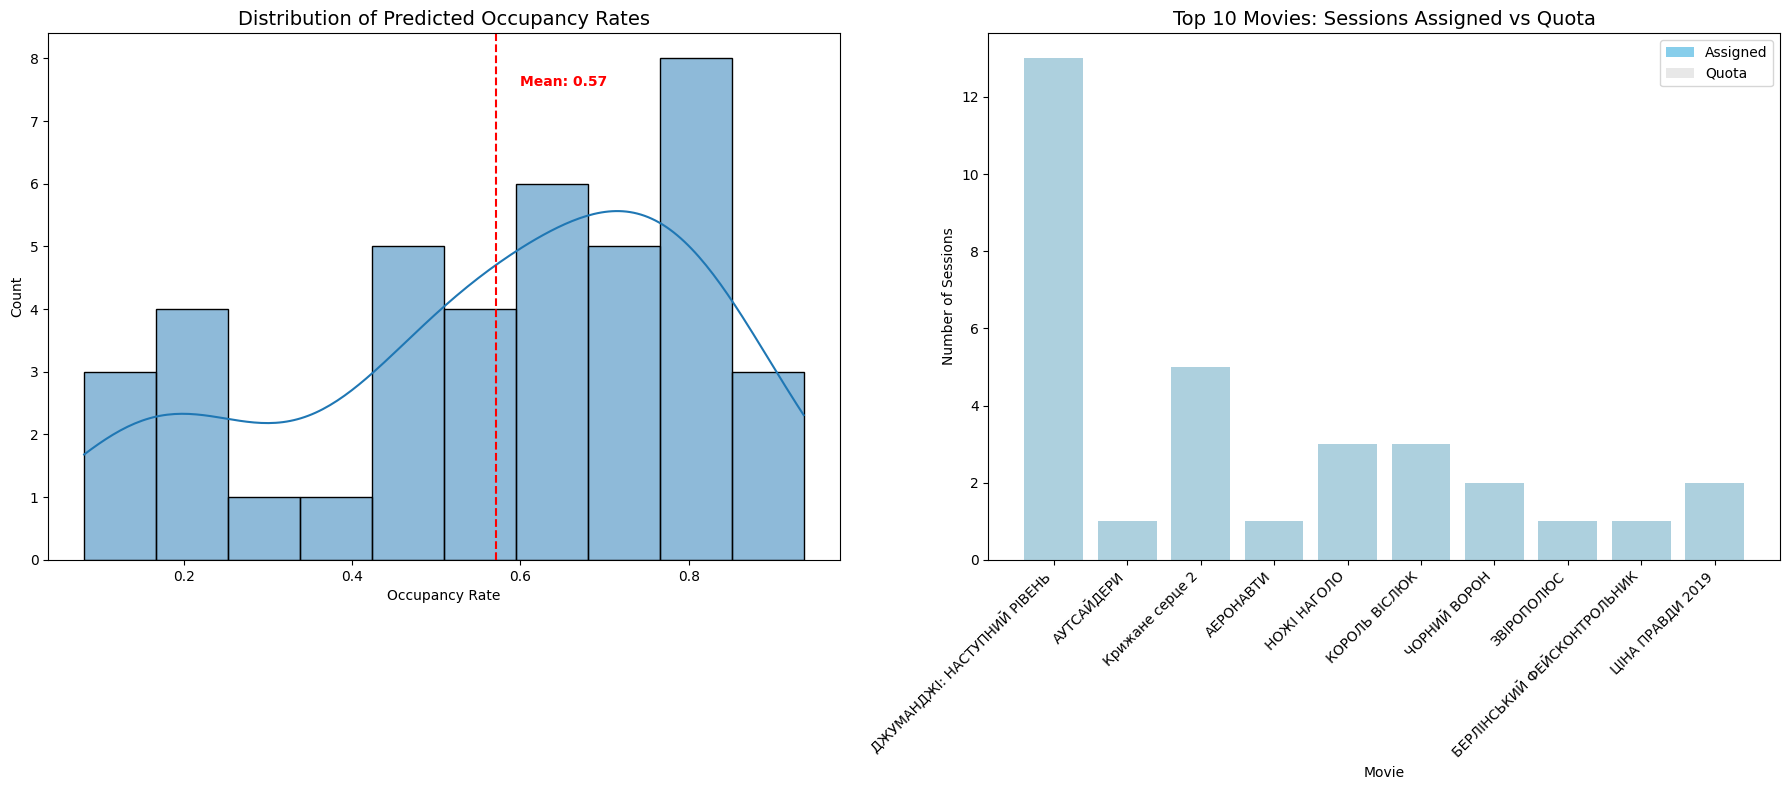

In [199]:
scheduling_results = execute_cinema_scheduling(df_, df_pairs)

In [200]:
display(scheduling_results['styled_table'])
plt.show()

,Session,Assigned Movie,Session Preference Rank,Movie Preference Rank,Predicted Occupancy Rate
18,670620.000000,ЧОРНИЙ ВОРОН,1,1,93.6%
14,670466.000000,КУРЄР,1,2,86.7%
36,670595.000000,21 МІСТ,6,2,85.4%
34,670559.000000,КОРОЛЬ ВІСЛЮК,6,1,84.9%
32,660170.000000,ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ,5,3,83.4%
2,670366.000000,Крижане серце 2,1,4,80.5%
24,670577.000000,ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ,3,6,78.2%
4,670384.000000,ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ,1,7,78.1%
20,670578.000000,КУРЄР,2,6,77.1%
11,670464.000000,ДЖУМАНДЖІ: НАСТУПНИЙ РІВЕНЬ,1,8,77.0%


Перевірка успішності оптимізації

In [201]:
df_prev = _df[_df['Cinema'] == 'Cinema 1L']

In [202]:
df_prev = df_prev[df_prev['Date'] == '15.12.2019']

/var/folders/bt/_x0h2pb92g55h0wvnfmyf_900000gp/T/ipykernel_30371/688484265.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df_prev = df_prev[df_prev['Date'] == '15.12.2019']


In [203]:
baseline_mean = df_prev['occupacyRate'].mean()
optimized_mean = df_pairs['pred_occupRate'].mean()

delta = optimized_mean - baseline_mean
pct_change = delta / baseline_mean * 100

print(f"Середня заповнюваність ДО: {baseline_mean:.2%}")
print(f"Середня заповнюваність ПІСЛЯ: {optimized_mean:.2%}")
print(f"Абсолютне покращення: {delta:.2%}")
print(f"Відносне покращення: {pct_change:.2f}%")

Середня заповнюваність ДО: 58.34%
Середня заповнюваність ПІСЛЯ: 49.44%
Абсолютне покращення: -8.91%
Відносне покращення: -15.26%


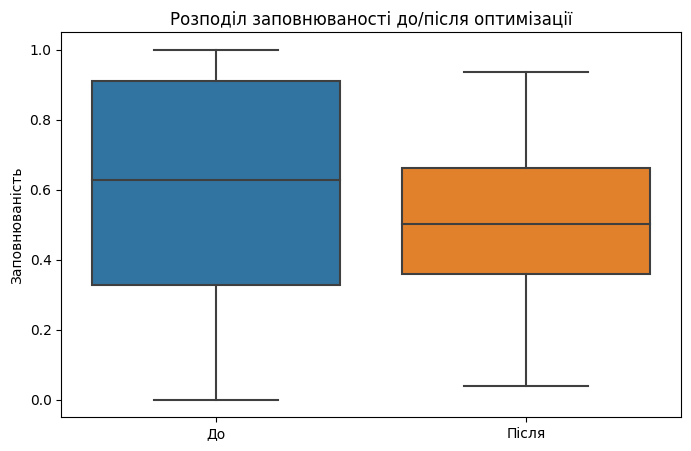

In [204]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[
    df_prev['occupacyRate'],
    df_pairs['pred_occupRate']
], orient='v')
plt.xticks([0,1], ['До','Після'])
plt.ylabel('Заповнюваність')
plt.title('Розподіл заповнюваності до/після оптимізації')
plt.show()

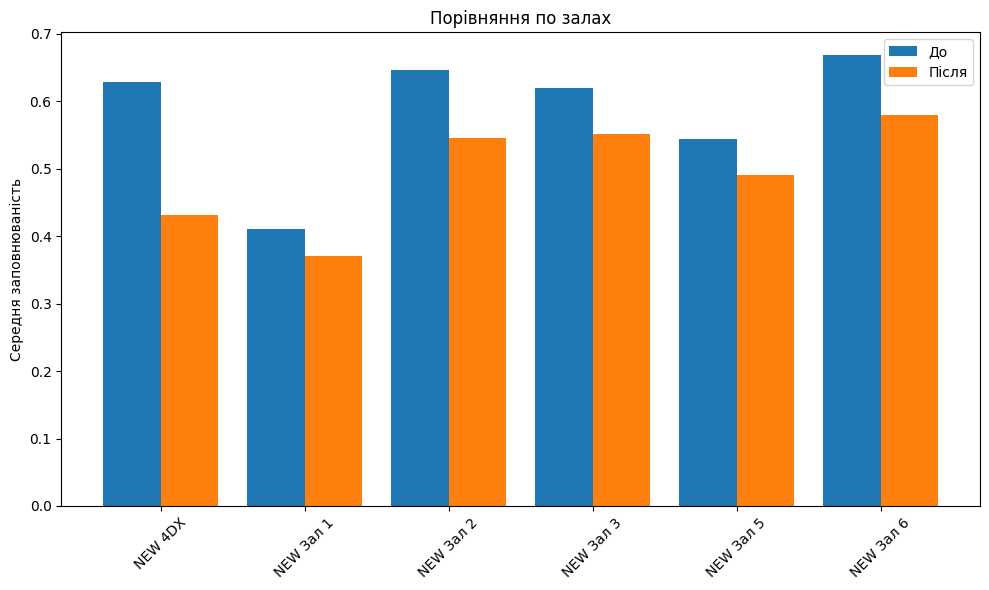

In [205]:
summary = pd.DataFrame({
    'Baseline': df_prev.groupby('Auditorium')['occupacyRate'].mean(),
    'Optimized': df_pairs.groupby('Auditorium')['pred_occupRate'].mean()
}).reset_index()

plt.figure(figsize=(10,6))
x = np.arange(len(summary))
w = 0.4
plt.bar(x - w/2, summary['Baseline'], w, label='До')
plt.bar(x + w/2, summary['Optimized'], w, label='Після')
plt.xticks(x, summary['Auditorium'], rotation=45)
plt.ylabel('Середня заповнюваність')
plt.title('Порівняння по залах')
plt.legend()
plt.tight_layout()
plt.show()

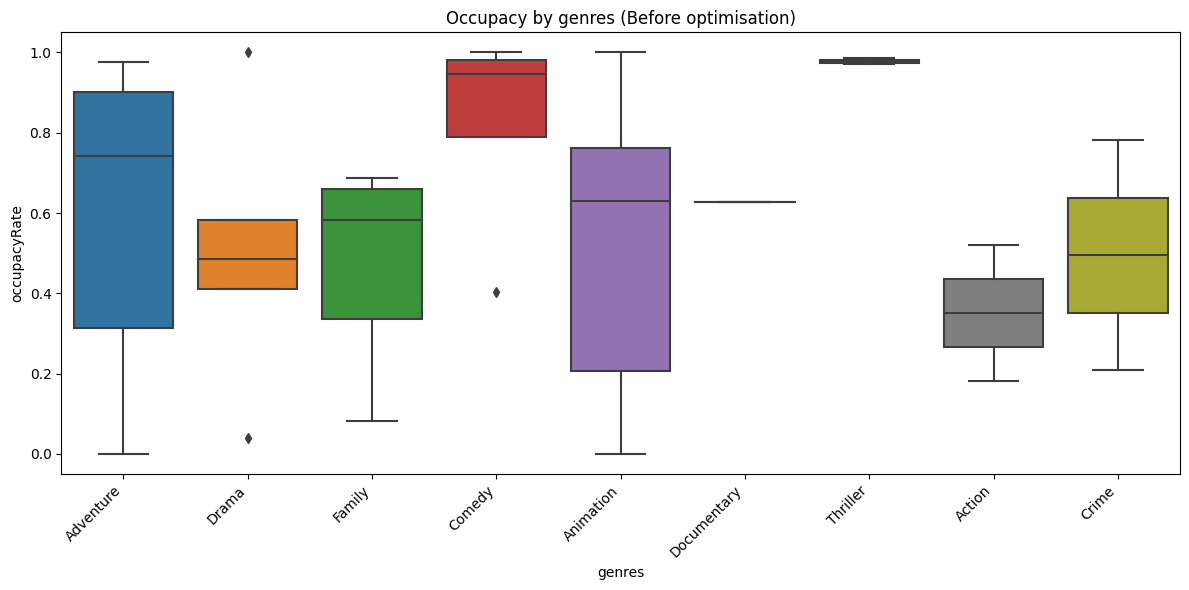

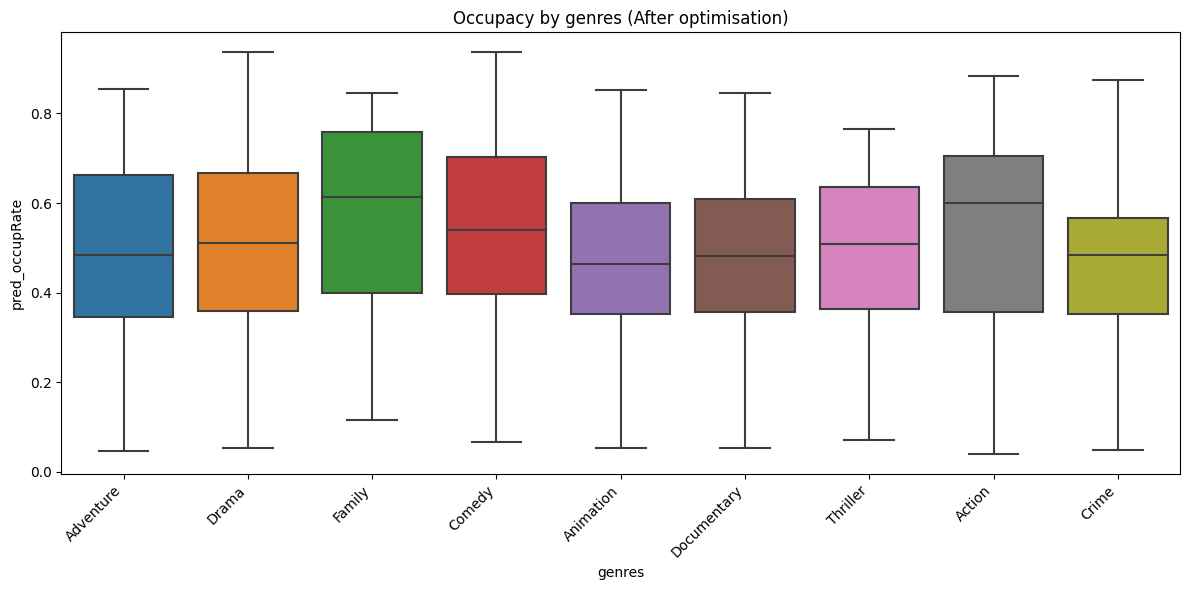

In [206]:
# Visualization by Genres
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_prev, x='genres', y='occupacyRate')
plt.xticks(rotation=45, ha='right')
plt.title('Occupacy by genres (Before optimisation)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pairs, x='genres', y='pred_occupRate')
plt.xticks(rotation=45, ha='right')
plt.title('Occupacy by genres (After optimisation)')
plt.tight_layout()
plt.show()

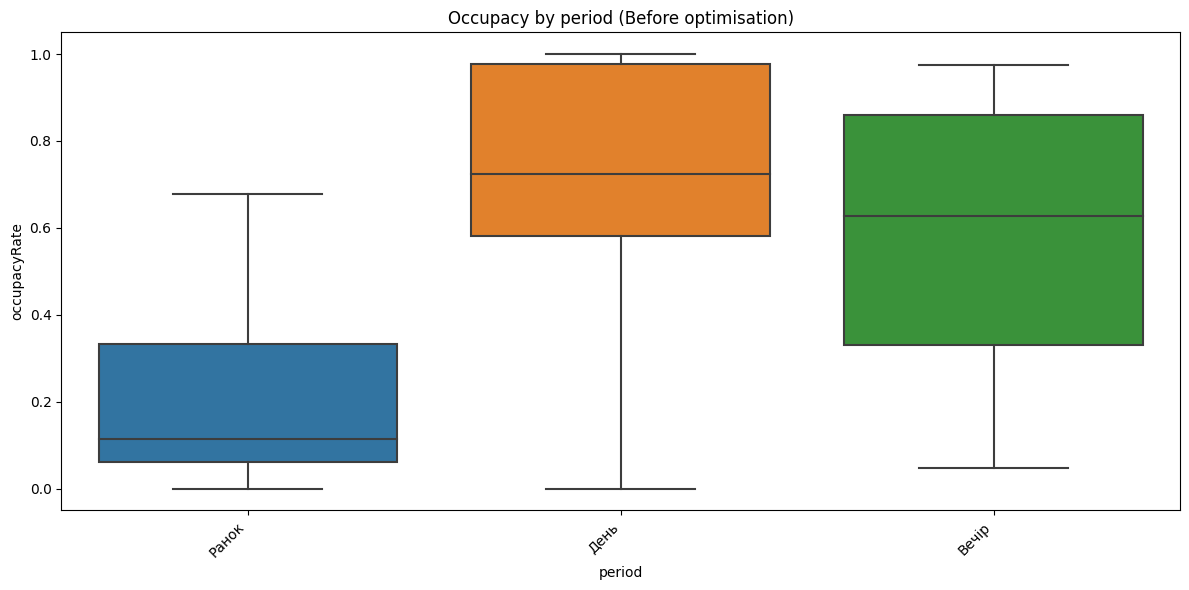

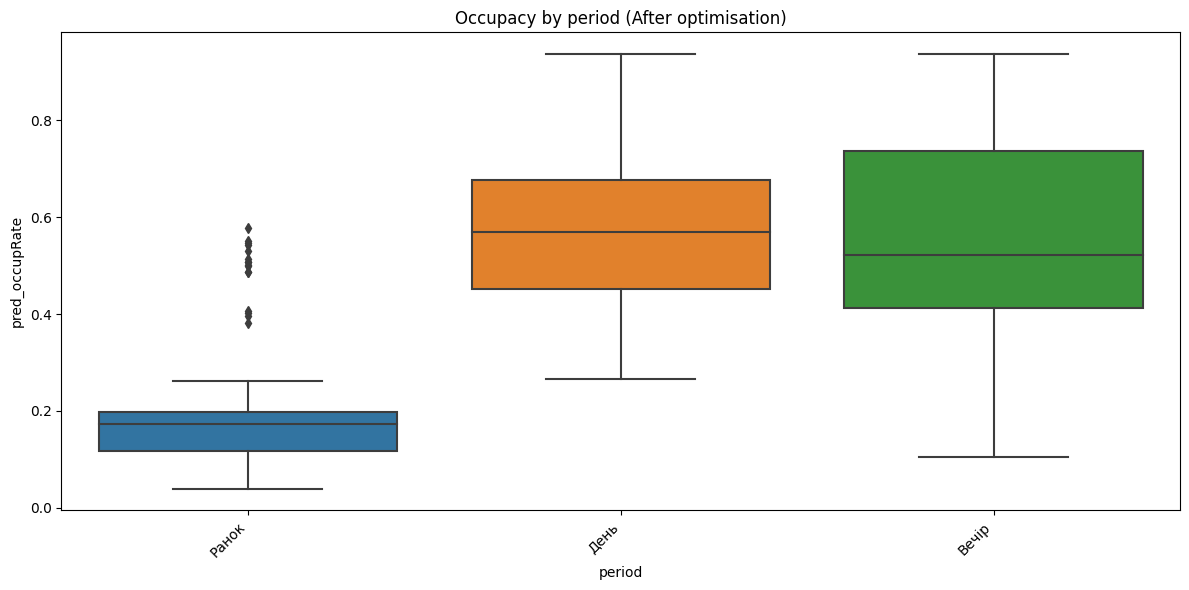

In [207]:
# Visualization by period
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_prev, x='period', y='occupacyRate')
plt.xticks(rotation=45, ha='right')
plt.title('Occupacy by period (Before optimisation)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pairs, x='period', y='pred_occupRate')
plt.xticks(rotation=45, ha='right')
plt.title('Occupacy by period (After optimisation)')
plt.tight_layout()
plt.show()